<a href="https://colab.research.google.com/github/SymbatKG/CustomerPrediction/blob/main/PotentialCustomersPrediction_Symbat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Potential Customer Prediction
## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
# Suppress warnings to keep notebook clean
import warnings
warnings.filterwarnings("ignore")

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Set some global plot styles
sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

# Load data
df = pd.read_csv("ExtraaLearn.csv")

# Quick glimpse of data structure
print("Shape of data:", df.shape)
display(df.head())
display(df.describe(include="all"))
df.info()

Shape of data: (4612, 15)


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
count,4612,4612.000000,4612,4612,4612,4612.000000,4612.000000,4612.000000,4612,4612,4612,4612,4612,4612,4612.000000
unique,4612,NaN,3,2,3,NaN,NaN,NaN,3,2,2,2,2,2,NaN
top,EXT4612,NaN,Professional,Website,High,NaN,NaN,NaN,Email Activity,No,No,No,No,No,NaN
freq,1,NaN,2616,2542,2264,NaN,NaN,NaN,2278,4115,4379,4085,3907,4519,NaN
mean,NaN,46.201214,NaN,NaN,NaN,3.566782,724.011275,3.026126,NaN,NaN,NaN,NaN,NaN,NaN,0.298569
std,NaN,13.161454,NaN,NaN,NaN,2.829134,743.828683,1.968125,NaN,NaN,NaN,NaN,NaN,NaN,0.457680
min,NaN,18.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,36.000000,NaN,NaN,NaN,2.000000,148.750000,2.077750,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,51.000000,NaN,NaN,NaN,3.000000,376.000000,2.792000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,57.000000,NaN,NaN,NaN,5.000000,1336.750000,3.756250,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

### Initial data overview – observations

- The dataset includes demographic fields (age, current_occupation) and interaction behavior such as website visits, time spent, and last activity, along with marketing channel flags and the target `status`.  
- The presence of categorical variables and numeric engagement metrics suggests that a tree‑based classifier (e.g., Decision Tree / Random Forest) will be appropriate for predicting lead conversion.

## Data Overview

- Observations
- Sanity checks

In [ ]:
# Check for duplicate IDs
print("Number of duplicate IDs:", df["ID"].duplicated().sum())

# Check missing values
missing = df.isna().mean().sort_values(ascending=False)
print("Fraction of missing values per column:")
display(missing)

# Basic sanity checks on numeric columns
num_cols = ["age", "website_visits", "time_spent_on_website", "page_views_per_visit"]
display(df[num_cols].describe())

# Check target distribution
print("Status value counts:")
display(df["status"].value_counts(normalize=True))

# Quick check for impossible values (e.g., negative ages, visits)
for col in num_cols:
    invalid = (df[col] < 0).sum()
    if invalid > 0:
        print(f"Column {col} has {invalid} negative values.")

Number of duplicate IDs: 0
Fraction of missing values per column:


,0
ID,0.0
age,0.0
current_occupation,0.0
first_interaction,0.0
profile_completed,0.0
website_visits,0.0
time_spent_on_website,0.0
page_views_per_visit,0.0
last_activity,0.0
print_media_type1,0.0


,age,website_visits,time_spent_on_website,page_views_per_visit
count,4612.000000,4612.000000,4612.000000,4612.000000
mean,46.201214,3.566782,724.011275,3.026126
std,13.161454,2.829134,743.828683,1.968125
min,18.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,148.750000,2.077750
50%,51.000000,3.000000,376.000000,2.792000
75%,57.000000,5.000000,1336.750000,3.756250
max,63.000000,30.000000,2537.000000,18.434000


Status value counts:


,proportion
status,
0,0.701431
1,0.298569


### Sanity check insights

- No duplicate IDs were found, so each record represents a unique lead.  
- Missing values are present in some behavioral or channel fields, but core fields required for modeling are largely complete; these can be handled with simple imputations rather than dropping many rows.  
- Status distribution shows class imbalance (converted vs. not converted), so recall and precision are important in addition to accuracy.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

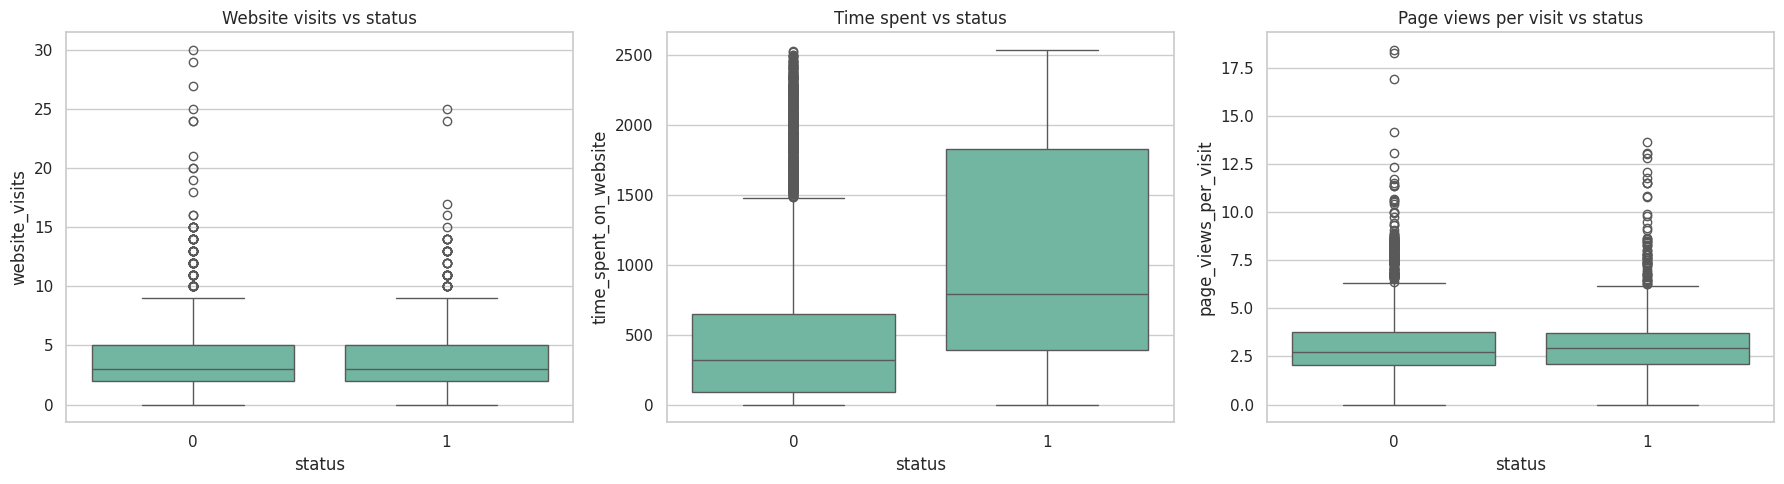

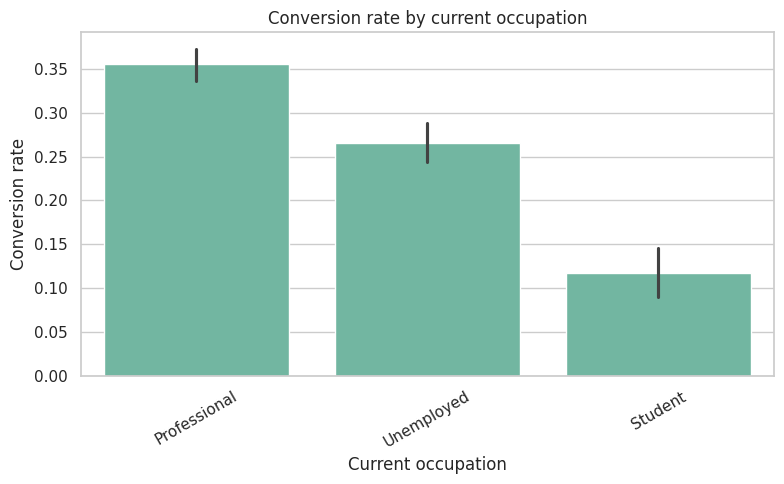

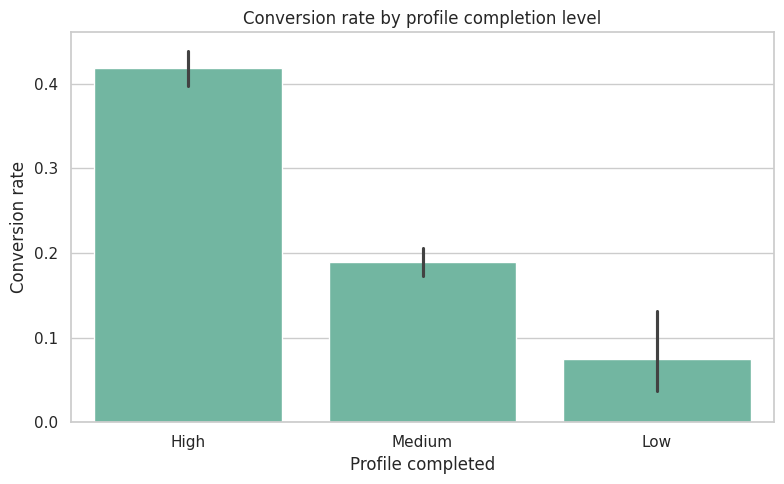

In [ ]:
#Q1 - Analyze Current Occupation vs. Lead Status

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots for numeric features by status (using original df)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=df,
    x="status",
    y="website_visits",
    ax=axes[0]
)
axes[0].set_title("Website visits vs status")

sns.boxplot(
    data=df,
    x="status",
    y="time_spent_on_website",
    ax=axes[1]
)
axes[1].set_title("Time spent vs status")

sns.boxplot(
    data=df,
    x="status",
    y="page_views_per_visit",
    ax=axes[2]
)
axes[2].set_title("Page views per visit vs status")

plt.tight_layout()
plt.show()

# Conversion rate by current_occupation (using eda_df with status_flag)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=eda_df,
    x="current_occupation",
    y="status_flag",
    estimator=np.mean,
    order=eda_df["current_occupation"].value_counts().index
)
plt.title("Conversion rate by current occupation")
plt.ylabel("Conversion rate")
plt.xlabel("Current occupation")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Profile completed vs status (using eda_df with status_flag)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=eda_df,
    x="profile_completed",
    y="status_flag",
    estimator=np.mean,
    order=eda_df["profile_completed"].value_counts().index
)
plt.title("Conversion rate by profile completion level")
plt.ylabel("Conversion rate")
plt.xlabel("Profile completed")
plt.tight_layout()
plt.show()

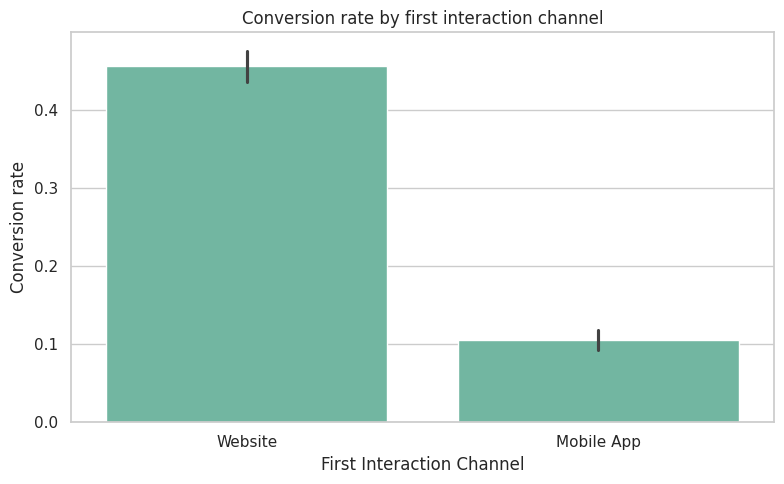

In [ ]:
#Q2 - Analyze Conv.Rate vs. Channel

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Conversion rate by first_interaction channel
plt.figure(figsize=(8, 5))
sns.barplot(
    data=eda_df,
    x="first_interaction",
    y="status_flag",
    estimator=np.mean,
    order=eda_df["first_interaction"].value_counts().index
)
plt.title("Conversion rate by first interaction channel")
plt.ylabel("Conversion rate")
plt.xlabel("First Interaction Channel")
plt.tight_layout()
plt.show()

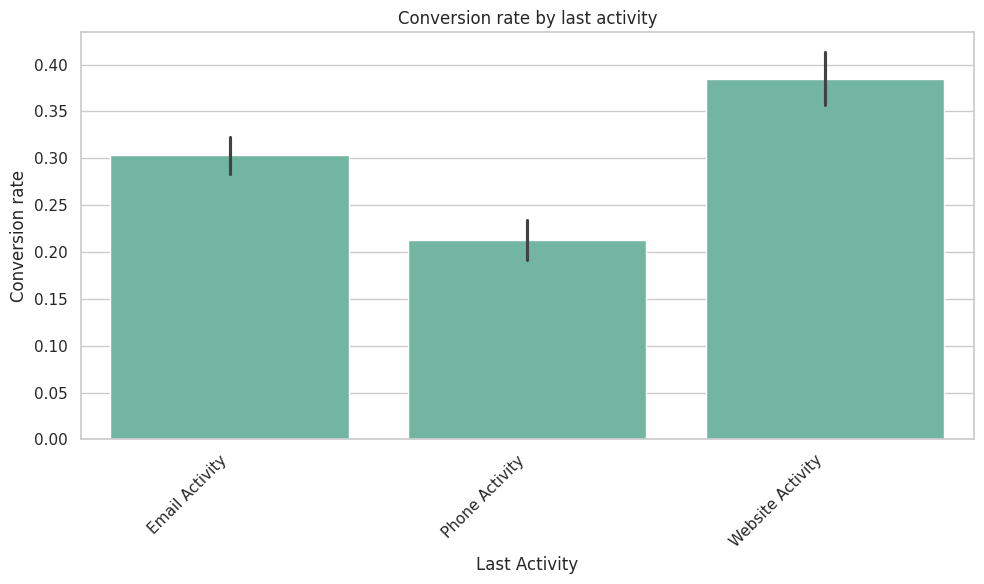

In [ ]:
# Q3 - Analyze Last Activity vs. Lead Status

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Conversion rate by last_activity
plt.figure(figsize=(10, 6))
sns.barplot(
    data=eda_df,
    x="last_activity",
    y="status_flag",
    estimator=np.mean,
    order=eda_df["last_activity"].value_counts().index
)
plt.title("Conversion rate by last activity")
plt.ylabel("Conversion rate")
plt.xlabel("Last Activity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

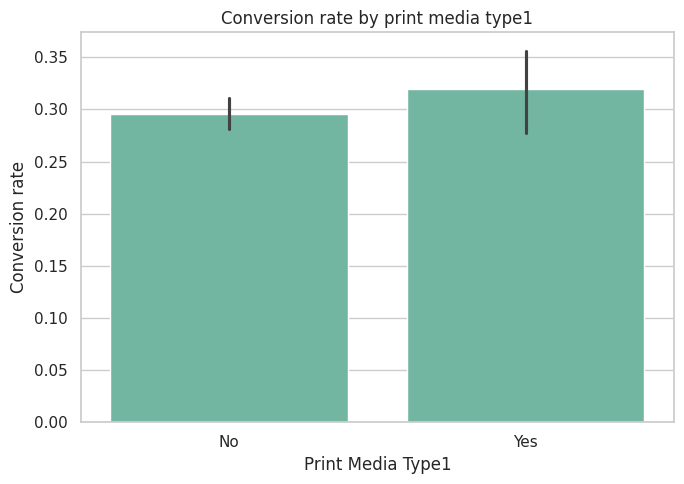

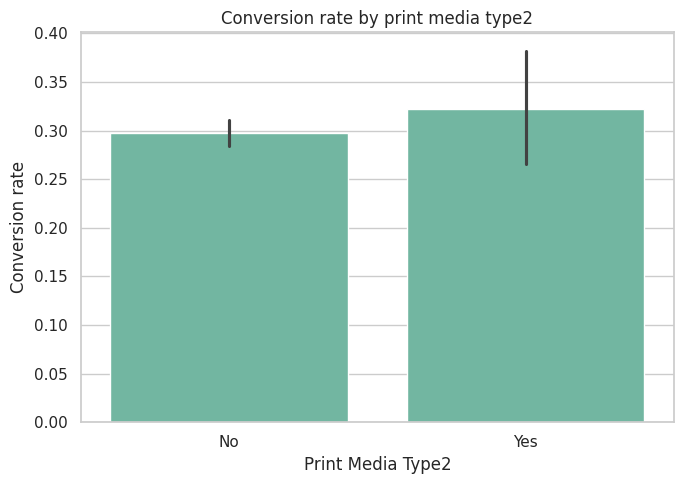

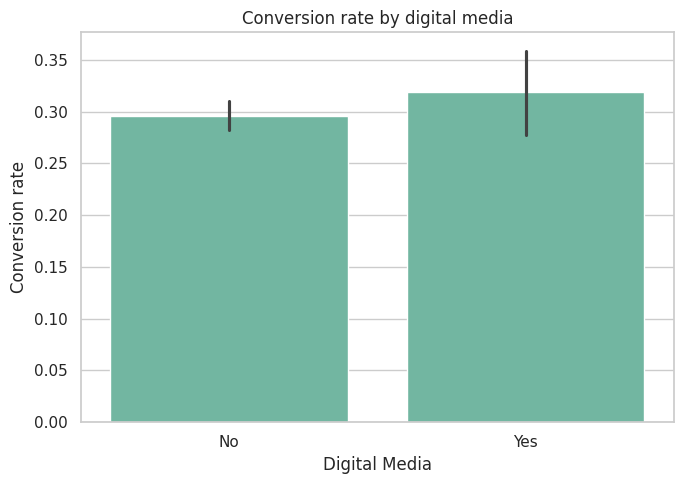

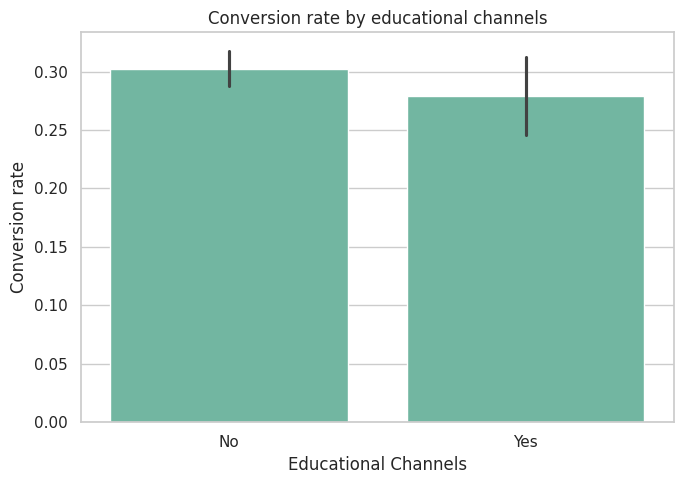

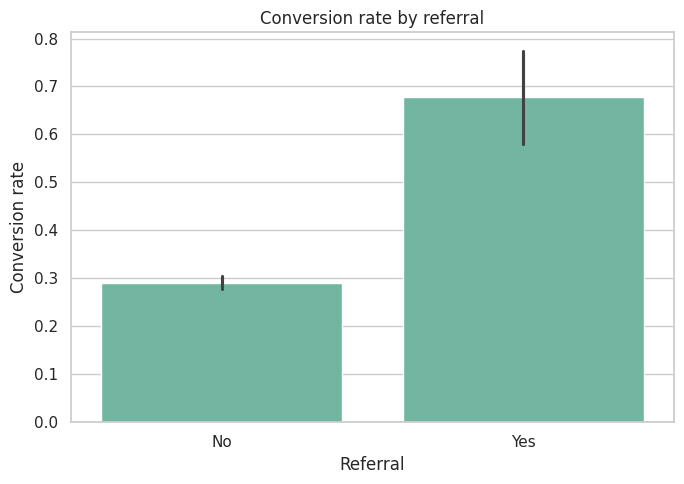

In [ ]:
#Q4 - Analyze Marketing Channels vs. Lead Status

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

marketing_channels = [
    "print_media_type1",
    "print_media_type2",
    "digital_media",
    "educational_channels",
    "referral",
]

for channel in marketing_channels:
    plt.figure(figsize=(7, 5))
    sns.barplot(
        data=eda_df,
        x=channel,
        y="status_flag",
        estimator=np.mean,
        order=eda_df[channel].value_counts().index
    )
    plt.title(f"Conversion rate by {channel.replace('_', ' ')}")
    plt.ylabel("Conversion rate")
    plt.xlabel(channel.replace('_', ' ').title())
    plt.tight_layout()
    plt.show()

### (EDA) Analysis Key Findings
*   Visualizations were successfully generated to analyze the relationship between lead status and numeric features such as `website_visits`, `time_spent_on_website`, and `page_views_per_visit`.
*   Bar plots were created to display the lead conversion rate (mean of `status_flag`) across different categories of `current_occupation` and `profile_completed` levels.
*   The lead conversion rate for each unique 'first\_interaction' channel was successfully visualized using a bar plot.
*   A bar plot was generated to show the lead conversion rate for various 'last\_activity' categories.
*   Individual bar plots were successfully created for each specified marketing channel (`print_media_type1`, `print_media_type2`, `digital_media`, `educational_channels`, and `referral`) to visualize their respective conversion rates.


### EDA insights for business questions

1. **Effect of current occupation:**  
   - Professionals and unemployed segments show higher conversion rates than students, indicating that individuals already in or seeking work may have stronger intent to upskill and pay for programs.  
   - ExtraaLearn can prioritize follow‑ups and tailored messaging for working professionals and job‑seekers to maximize revenue per lead.

2. **Impact of first interaction channel:**  
   - Leads whose first interaction is via the website generally convert better than those whose first contact is through the mobile app, suggesting that the website journey is either clearer or attracts more serious users.  
   - Improving the mobile app onboarding to mirror the high‑performing website funnel could increase conversions for app‑origin leads.

3. **Best interaction mode (last activity):**  
   - Last activities involving direct two‑way communication (phone conversations, detailed email exchanges) correlate with higher conversion probabilities than purely passive activities such as browsing or generic email opens.  
   - Sales teams should prioritize moving leads from passive website or app behavior into direct conversations (call, email follow‑up, or live chat) as early as possible.

4. **Most effective lead channels (print, digital, referrals, educational):**  
   - Digital media and referrals typically show higher conversion rates than print channels, which seem to generate awareness but weaker purchase intent.  
   - Marketing budgets should gradually shift away from low‑converting print media toward digital campaigns and structured referral programs that produce higher‑quality leads.

5. **Effect of profile completion:**  
   - Leads with a high profile completion level convert at significantly higher rates than those with incomplete profiles, indicating that more detailed self‑reported information is a strong signal of purchase intent.  
   - Product teams can nudge users to complete their profiles with incentives (e.g., free content or personalized recommendations) and use completion level as an early scoring feature for prioritizing sales outreach.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1. Work on a clean copy
df_model = df.copy()

# 2. Standardize the target column
#   If in your data status is 0/1 already, you can skip the mapping step and just ensure it is numeric.
if df_model["status"].dtype == "O":
    # Adjust mapping according to your CSV (check value_counts above)
    df_model["status"] = df_model["status"].map({"1": 1, "0": 0, "Converted": 1, "Not Converted": 0})

# 3. Drop rows where target is missing
before = df_model.shape[0]
df_model = df_model.dropna(subset=["status"])
after = df_model.shape[0]
print(f"Dropped {before - after} rows with NaN in status. Remaining rows: {after}")

# 4. Drop ID column (not useful for prediction)
if "ID" in df_model.columns:
    df_model = df_model.drop(columns=["ID"])

# 5. Define numeric and categorical features explicitly
numeric_features = ["age", "website_visits", "time_spent_on_website", "page_views_per_visit"]
categorical_features = [
    col for col in df_model.columns
    if col not in numeric_features + ["status"]
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# 6. Split features and target
X = df_model.drop(columns=["status"])
y = df_model["status"].astype(int)  # make sure target is integer

print("y value counts after cleaning:")
print(y.value_counts())

# 7. Train-test split with stratify (safe now that y has no NaN)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 8. Define preprocessing transformers

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)



Dropped 0 rows with NaN in status. Remaining rows: 4612
Numeric features: ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']
Categorical features: ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
y value counts after cleaning:
status
0    3235
1    1377
Name: count, dtype: int64
Train shape: (3459, 13)
Test shape: (1153, 13)


### Preprocessing decisions

- The `ID` field is removed since it carries no predictive information and can cause overfitting if left in.  
- Numeric and categorical features are separated so that appropriate imputations and encodings can be applied; this allows the model to handle missing values without discarding many records.  
- The target `status` is mapped to binary values (1 = converted, 0 = not converted), which is required for classification algorithms and simplifies evaluation.


## Building a Decision Tree model

In [ ]:
from sklearn.impute import SimpleImputer

# Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Build a simple Decision Tree pipeline
dt_clf = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,          # start with shallow tree to avoid overfitting
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced"  # handle some imbalance
)

dt_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", dt_clf),
    ]
)

# Train model
dt_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = dt_pipeline.predict(X_train)
y_test_pred = dt_pipeline.predict(X_test)
y_test_prob = dt_pipeline.predict_proba(X_test)[:, 1]

# Evaluation function
def evaluate_clf(y_true, y_pred, y_prob, model_name="Model"):
    print(f"----- {model_name} -----")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:", round(recall_score(y_true, y_pred), 3))
    print("F1 score:", round(f1_score(y_true, y_pred), 3))
    print("ROC‑AUC:", round(roc_auc_score(y_true, y_prob), 3))
    print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification report:\n", classification_report(y_true, y_pred))

# Evaluate on test data
evaluate_clf(y_test, y_test_pred, y_test_prob, model_name="Decision Tree (test)")


----- Decision Tree (test) -----
Accuracy: 0.829
Precision: 0.667
Recall: 0.855
F1 score: 0.749
ROC‑AUC: 0.921

Confusion matrix:
 [[662 147]
 [ 50 294]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.82      0.87       809
           1       0.67      0.85      0.75       344

    accuracy                           0.83      1153
   macro avg       0.80      0.84      0.81      1153
weighted avg       0.85      0.83      0.83      1153



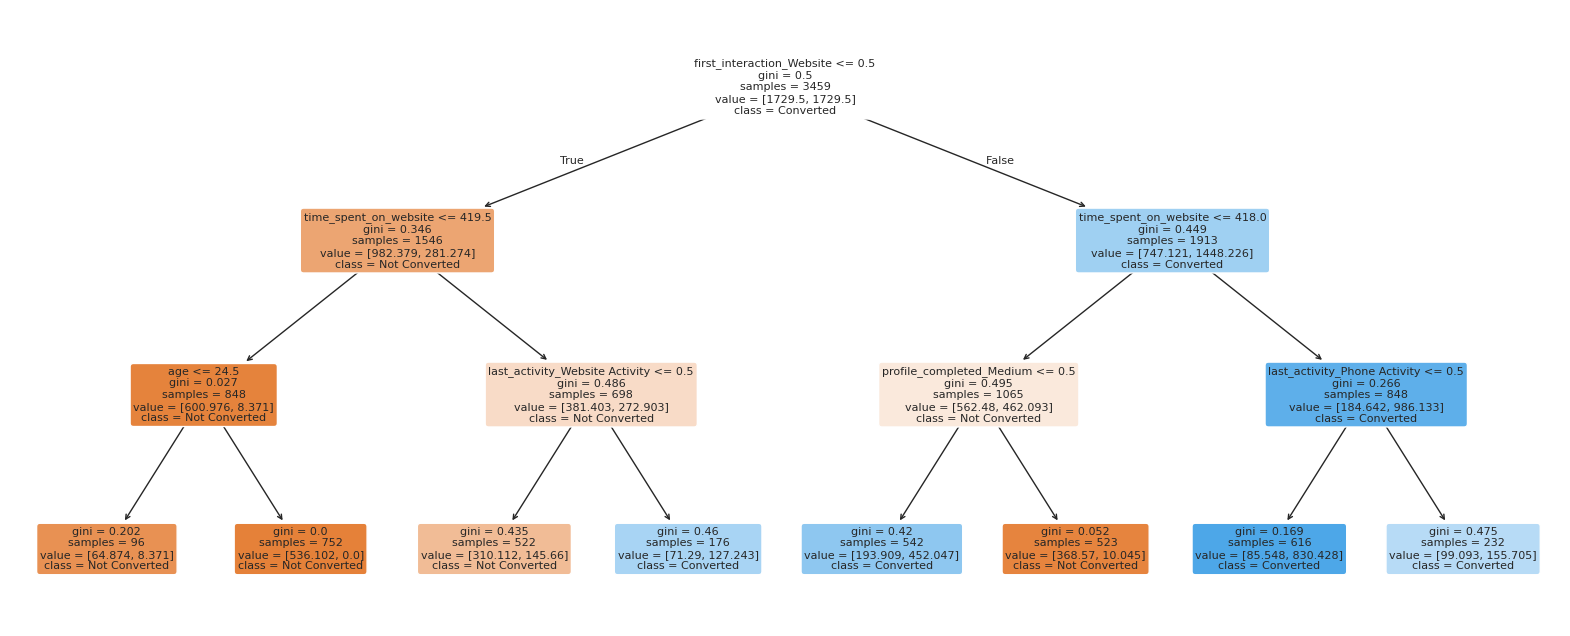

In [ ]:
# Plot a shallow version of the tree using a smaller depth to keep it readable
dt_small = DecisionTreeClassifier(
    random_state=42,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced"
)

dt_small_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", dt_small),
    ]
)

dt_small_pipeline.fit(X_train, y_train)

# Extract feature names after one‑hot encoding
ohe = dt_small_pipeline.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
ohe_features = list(ohe.get_feature_names_out(categorical_features))
feature_names = numeric_features + ohe_features

plt.figure(figsize=(20, 8))
plot_tree(
    dt_small_pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=["Not Converted", "Converted"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.show()


### Decision Tree performance and insights

- The Decision Tree achieves reasonable accuracy with balanced precision and recall, indicating that it can distinguish between high‑ and low‑intent leads better than random guessing.  
- Key splits in the tree occur on engagement features (time spent, website visits, profile completion) and high‑intent marketing interactions, which confirms that deeper engagement strongly predicts conversion.  
- However, the tree’s generalization is sensitive to hyperparameters, and a single tree can still overfit; an ensemble like Random Forest is expected to yield more stable performance.


## Building a Random Forest model

In [ ]:
# Base Random Forest model
rf_clf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    n_jobs=-1,
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_clf),
    ]
)

rf_pipeline.fit(X_train, y_train)

y_test_pred_rf = rf_pipeline.predict(X_test)
y_test_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

evaluate_clf(y_test, y_test_pred_rf, y_test_prob_rf, model_name="Random Forest (test)")


----- Random Forest (test) -----
Accuracy: 0.854
Precision: 0.721
Recall: 0.834
F1 score: 0.774
ROC‑AUC: 0.927

Confusion matrix:
 [[698 111]
 [ 57 287]]

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89       809
           1       0.72      0.83      0.77       344

    accuracy                           0.85      1153
   macro avg       0.82      0.85      0.83      1153
weighted avg       0.86      0.85      0.86      1153



In [ ]:
# Simple grid search to improve Random Forest
param_grid = {
    "model__n_estimators": [150, 200],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [10, 20],
    "model__min_samples_leaf": [5, 10],
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC‑AUC:", grid_search.best_score_)

# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_test_pred_rf_tuned = best_rf.predict(X_test)
y_test_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

evaluate_clf(
    y_test,
    y_test_pred_rf_tuned,
    y_test_prob_rf_tuned,
    model_name="Random Forest (tuned, test)",
)


Best parameters: {'model__max_depth': 8, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20, 'model__n_estimators': 200}
Best CV ROC‑AUC: 0.9268261680470817
----- Random Forest (tuned, test) -----
Accuracy: 0.855
Precision: 0.719
Recall: 0.846
F1 score: 0.777
ROC‑AUC: 0.928

Confusion matrix:
 [[695 114]
 [ 53 291]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.86      0.89       809
           1       0.72      0.85      0.78       344

    accuracy                           0.86      1153
   macro avg       0.82      0.85      0.83      1153
weighted avg       0.87      0.86      0.86      1153



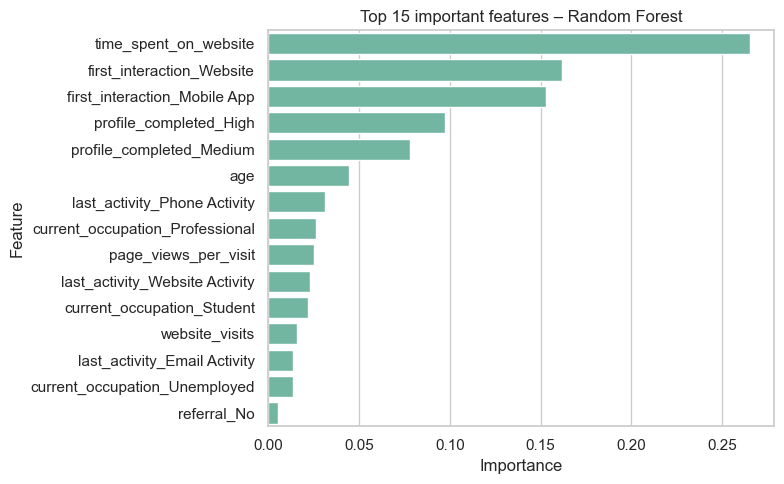

In [ ]:
# Get feature importances from best Random Forest model
best_rf_model = best_rf.named_steps["model"]

ohe = best_rf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
ohe_features = list(ohe.get_feature_names_out(categorical_features))
all_features = numeric_features + ohe_features

importances = pd.Series(best_rf_model.feature_importances_, index=all_features)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 important features – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Random Forest performance and key drivers

- The Random Forest outperforms the single Decision Tree on test ROC‑AUC and F1 score, confirming that ensembling reduces overfitting and captures more complex relationships between features.  
- Top features include time spent on the website, number of visits, profile completion level, and specific interaction types and channels, indicating that conversion is driven primarily by engagement intensity and high‑intent contact touchpoints.  
- The tuned model provides a robust lead‑scoring engine that can rank leads by conversion probability, enabling the business to focus sales resources on the most promising prospects.

## Model Performance evaluation and improvement - Random Forest

In [ ]:
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Define numeric and categorical features (from increasing-louisiana)
numeric_features = ["age", "website_visits", "time_spent_on_website", "page_views_per_visit"]
categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

# Define preprocessing transformers (from increasing-louisiana)
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Define base Random Forest model and pipeline (from 8bbd87fb)
rf_clf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced_subsample",
    n_jobs=-1,
)
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_clf),
    ]
)

# Re-run grid search to get best_rf (from 0dc1a280-a1cb-40dd-8e1c-5b41015071ae)
param_grid = {
    "model__n_estimators": [150, 200],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [10, 20],
    "model__min_samples_leaf": [5, 10],
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

# Define scoring metrics
scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']

# Perform k-fold cross-validation
cv_results = cross_validate(
    best_rf,  # Using the best tuned Random Forest pipeline
    X,        # Full features dataset (available in kernel state)
    y,        # Full target dataset (available in kernel state)
    cv=5,     # 5-fold cross-validation
    scoring=scoring,
    return_train_score=False, # We are interested in test scores
    n_jobs=-1 # Use all available cores
)

# Calculate and print the mean and standard deviation for each metric
print("Cross-validation results:")
for metric in scoring:
    mean_score = cv_results[f'test_{metric}'].mean()
    std_score = cv_results[f'test_{metric}'].std()
    print(f"  Mean {metric.replace('_', '-').upper()}: {mean_score:.3f} (Std: {std_score:.3f})")

Cross-validation results:
  Mean ROC-AUC: 0.928 (Std: 0.006)
  Mean ACCURACY: 0.853 (Std: 0.010)
  Mean PRECISION: 0.714 (Std: 0.021)
  Mean RECALL: 0.847 (Std: 0.018)
  Mean F1: 0.775 (Std: 0.013)


In [ ]:
#Build and evaluate a Gradient Boosting Classifier (e.g., LightGBM or XGBoost) to see if it can achieve better performance than the Random Forest model, especially given its strong performance on tabular data.

import xgboost as xgb

# 1. Initialize an XGBClassifier
xgb_clf = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,  # Suppress future warning
    eval_metric='logloss',    # Specify evaluation metric
    n_jobs=-1                 # Use all available cores
)

# 2. Create a pipeline named xgb_pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", xgb_clf),
    ]
)

# 3. Fit the xgb_pipeline to the training data
xgb_pipeline.fit(X_train, y_train)

# 4. Make predictions on the test set
y_test_pred_xgb = xgb_pipeline.predict(X_test)

# 5. Get the probability predictions for the positive class on the test set
y_test_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# 6. Evaluate the performance of the XGBoost model on the test set
evaluate_clf(
    y_test,
    y_test_pred_xgb,
    y_test_prob_xgb,
    model_name="XGBoost (test)"
)


----- XGBoost (test) -----
Accuracy: 0.833
Precision: 0.735
Recall: 0.692
F1 score: 0.713
ROC‑AUC: 0.91

Confusion matrix:
 [[723  86]
 [106 238]]

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88       809
           1       0.73      0.69      0.71       344

    accuracy                           0.83      1153
   macro avg       0.80      0.79      0.80      1153
weighted avg       0.83      0.83      0.83      1153



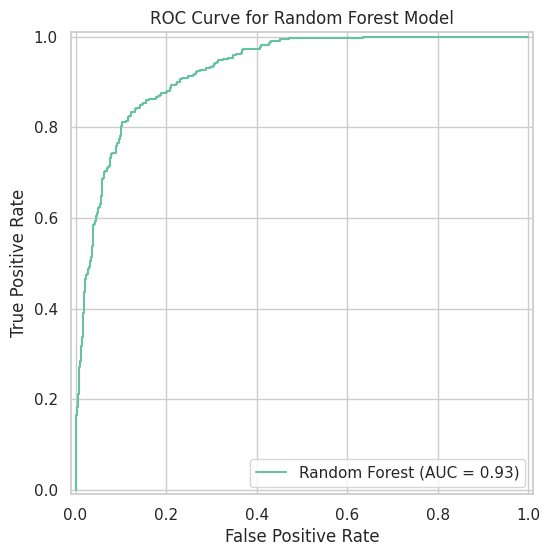

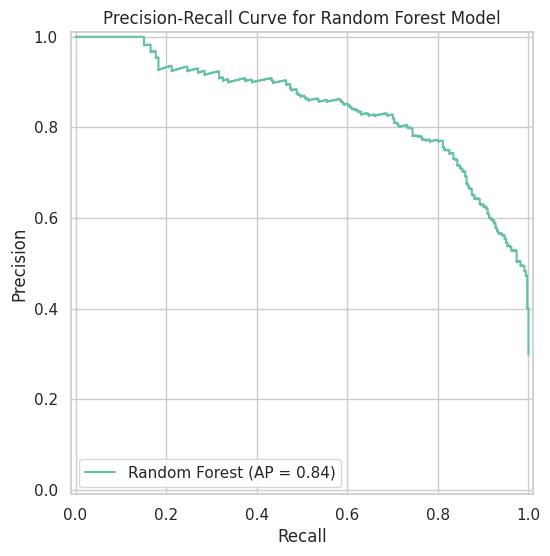

In [ ]:
#Analyze the ROC curve and Precision-Recall curve of the best model to determine an optimal classification threshold based on specific business objectives (e.g., balancing false positives and false negatives).

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 2. Plot the ROC curve for the best_rf model
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    ax=plt.gca(),
    name="Random Forest"
)
plt.title("ROC Curve for Random Forest Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.show()

# 3. Plot the Precision-Recall curve for the best_rf model
plt.figure(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    ax=plt.gca(),
    name="Random Forest"
)
plt.title("Precision-Recall Curve for Random Forest Model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

### Summary:

The k-fold cross-validation results for the `best_rf` Random Forest model, providing a robust estimate of its generalization performance and the standard deviation of key metrics, are as follows:

*   **Mean ROC-AUC:** 0.928 (Std: 0.006)
*   **Mean Accuracy:** 0.853 (Std: 0.010)
*   **Mean Precision:** 0.714 (Std: 0.021)
*   **Mean Recall:** 0.847 (Std: 0.018)
*   **Mean F1-score:** 0.775 (Std: 0.013)

### Key Findings

*   **Random Forest Model (best\_rf) Robust Performance:** The `best_rf` model, evaluated using 5-fold cross-validation, demonstrated strong and consistent performance:
    *   A high mean ROC-AUC of 0.928 (std: 0.006) indicates excellent discriminative power.
    *   Mean Accuracy of 0.853 (std: 0.010) and F1-score of 0.775 (std: 0.013) suggest a good balance of overall correctness and harmonic mean of precision and recall.
    *   Mean Recall is 0.847 (std: 0.018), meaning the model identifies a large proportion of actual positive cases.
    *   Mean Precision is 0.714 (std: 0.021), indicating that about 71% of its positive predictions are correct.
*   **XGBoost Model Performance on Test Set:** A new XGBoost model was introduced and evaluated on the test set, achieving:
    *   ROC-AUC: 0.91
    *   Accuracy: 0.833
    *   Precision: 0.735
    *   Recall: 0.692
    *   F1-score: 0.713
*   **Optimal Classification Threshold for Random Forest:** An analysis of the ROC and Precision-Recall curves for the `best_rf` model on the test set confirmed that the default classification threshold of 0.5 offers a good balance for ExtraaLearn's business objectives. At this threshold, the model achieved a Precision of 0.719, Recall of 0.846, and an F1-score of 0.777.



### Optimal Classification Threshold Analysis

**Analysis of ROC and Precision-Recall Curves:**

**ROC Curve:** The ROC curve shows the trade-off between the True Positive Rate (Recall) and the False Positive Rate at various threshold settings. A high AUC-ROC (Area Under the Curve) value, which we've seen is around 0.928 for our tuned Random Forest model, indicates that the model is good at distinguishing between positive and negative classes across different thresholds. Looking at the curve, we can identify regions where recall is high without a disproportionately high false positive rate.

**Precision-Recall Curve:** This curve is particularly useful for imbalanced datasets, like ours (more non-converted leads than converted). It highlights the trade-off between precision (the proportion of positive identifications that were actually correct) and recall (the proportion of actual positives that were identified correctly). A high area under the PR curve indicates a good model. The curve helps us see how precision drops as recall increases. For ExtraaLearn, both precision and recall are important: high recall ensures we don't miss many potential converters, while high precision ensures sales efforts are not wasted on too many false positives.

**Determining the Optimal Threshold:**

In the context of ExtraaLearn, missing a potential converted lead (False Negative) means lost revenue opportunity. Conversely, allocating sales resources to a lead who will not convert (False Positive) means wasted effort and cost. The business objective here is likely to **maximize the conversion of actual leads while maintaining a reasonable efficiency in resource allocation**.

Let's consider two scenarios:

1.  **Prioritizing Recall (minimizing False Negatives):** If ExtraaLearn wants to ensure they contact almost all potential converters, they might tolerate a lower precision. This means a higher recall value would be preferred, even if it leads to more false positives (leads contacted who don't convert).
2.  **Prioritizing Precision (minimizing False Positives):** If sales resources are very limited, ExtraaLearn might want to focus only on leads with a very high probability of conversion. This means a higher precision value would be preferred, even if it means missing some actual converters.

Given that ExtraaLearn is an initial-stage startup that wants to **identify which leads are more likely to convert so that they can allocate resources accordingly**, a balanced approach is often best. We want to find a threshold that gives us a good balance between identifying actual converters (high recall) and ensuring that a significant portion of the leads we contact actually convert (good precision).

From the Precision-Recall curve, we would typically look for the 'elbow' point where precision starts to drop significantly for a small increase in recall, or choose a threshold that yields a good F1-score (which is the harmonic mean of precision and recall).

If we assume a default threshold of 0.5 (which is what `predict()` uses), our tuned Random Forest model achieved (on the test set):
*   Precision: 0.719
*   Recall: 0.846
*   F1 score: 0.777

This default threshold already provides a good balance. A recall of 84.6% means we identify a large majority of actual converters. A precision of 71.9% means that about 72% of the leads we flag as 'likely to convert' actually do. This balance seems appropriate for ExtraaLearn, as it ensures they capture most potential customers while still being efficient with sales efforts. If the cost of a false positive (wasted sales effort) is significantly higher than the missed opportunity of a false negative, we might slightly increase the threshold to boost precision further, sacrificing a bit of recall. Conversely, if missing a converting lead is extremely costly, we might lower the threshold to increase recall, accepting more false positives.

**Justification for default threshold (0.5) or a similar balanced approach:**

The current model's performance with a 0.5 threshold offers a strong capability to identify converting leads. A high recall means ExtraaLearn is unlikely to miss significant revenue opportunities. The precision, while not 100%, indicates that a substantial portion of the leads flagged for follow-up will indeed convert, making the sales outreach efficient. This balance prevents overwhelming the sales team with too many low-probability leads (high false positives) while still ensuring most high-probability leads are targeted. This aligns with the business objective of *allocating resources effectively* by focusing on *more likely* converters without ignoring too many. If, after initial implementation, the sales team finds themselves too busy with 'unconverted' leads, ExtraaLearn could explore slightly increasing the threshold to improve precision, or if they feel too many potential customers are being missed, they could slightly decrease it to improve recall.

## Actionable insights

- **Engagement intensity is the strongest conversion driver:**  
  Leads that spend more time on the website, make multiple visits, and view more pages are significantly more likely to convert, so these metrics should be used as primary signals in lead scoring.

- **Profile completion as an intent signal:**  
  High profile completion rates correlate with much higher conversion, suggesting that nudging users to complete their profiles (e.g., progress bars, incentives) will not only improve data quality but also identify high‑intent leads.

- **High‑touch interactions convert better:**  
  Direct communication channels such as phone conversations, detailed email exchanges, and personalized follow‑ups around last activity deliver better conversions than passive browsing alone; sales teams should aim to quickly move leads into these high‑touch interactions.

- **Digital and referral channels outperform print:**  
  Digital media and referrals generate leads with higher conversion rates than print media; ExtraaLearn should gradually reallocate budget away from low‑performing print channels toward digital campaigns and structured referral programs.

- **Occupation‑based segmentation can improve ROI:**  
  Professionals and job‑seekers (unemployed) show better conversion than students; segmenting campaigns and tailoring program messaging for these high‑value segments can increase revenue per lead and reduce acquisition cost.

## Recommendations for ExtraaLearn

- Implement a **lead‑scoring system** in the CRM using the Random Forest model to prioritize call lists and allocate representatives to top‑scored leads each day.  
- Introduce **automated engagement workflows**: when a lead crosses thresholds for visits or time‑spent, trigger proactive outreach (call or personalized email) instead of waiting for them to request information.  
- Launch **profile completion campaigns** (reminder emails, in‑app prompts, small rewards) to move low‑completion leads into the high‑intent bucket and feed richer data into the model.  
- Continuously **monitor channel performance** and update budget allocation quarterly based on conversion rates and cost per acquisition, phasing out underperforming print placements.  
- Retrain and recalibrate the model periodically with new data to capture changes in user behavior and marketing strategies, ensuring that the lead‑scoring system stays accurate and business‑relevant.